In [1]:
!pip install --no-cache-dir "gymnasium[atari,accept-rom-license]"
!pip install torch torchvision
!pip install opencv-python matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 12.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of shimmy[atari] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 71.7 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.29.0
    Uninstalling gymnasium-0.29.0:
      Successfully uninstalled gymnasium-0.29.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stable-baselines3 2.1.0 requires gymnasium<0.30,>=0.28.1, but you have gymnasium 1.2.3 which is incompatible.
kaggle-environments 1.18.0 requires gymnasium==0.29.0, but you have gymnasium 1.2.3 which is incompat

In [2]:
# =============================================================================
# CELL 1: Imports & Setup
# =============================================================================

import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import random
import cv2
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List, Optional
import os

gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPUs: {torch.cuda.device_count()}")

# =============================================================================
# CELL 2: All Classes (DQNConfig, DQN, ReplayBuffer, DQNAgent)
# =============================================================================

@dataclass
class DQNConfig:
    env_name: str = "ALE/Seaquest-v5"
    total_episodes: int = 1000
    total_test_episodes: int = 20
    max_steps_per_episode: int = 10000
    learning_rate: float = 0.00025
    gamma: float = 0.99
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.00001
    buffer_size: int = 100000
    batch_size: int = 32
    min_buffer_size: int = 10000
    target_update_freq: int = 1000
    frame_height: int = 84
    frame_width: int = 84
    frame_stack: int = 4
    save_freq: int = 500
    log_freq: int = 50
    
    def to_dict(self):
        return {k: v for k, v in self.__dict__.items()}

class FramePreprocessor:
    def __init__(self, height=84, width=84):
        self.height, self.width = height, width
    
    def preprocess(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (self.width, self.height), interpolation=cv2.INTER_AREA)
        return resized.astype(np.float32) / 255.0

class FrameStacker:
    def __init__(self, stack_size=4):
        self.stack_size = stack_size
        self.frames = deque(maxlen=stack_size)
    
    def reset(self, frame):
        self.frames.clear()
        for _ in range(self.stack_size):
            self.frames.append(frame)
        return np.stack(self.frames, axis=0)
    
    def add_frame(self, frame):
        self.frames.append(frame)
        return np.stack(self.frames, axis=0)

Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Experience(state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    
    def __len__(self):
        return len(self.buffer)

class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        conv_out = self._get_conv_out(input_shape)
        self.fc1 = nn.Linear(conv_out, 512)
        self.fc2 = nn.Linear(512, n_actions)
    
    def _get_conv_out(self, shape):
        o = torch.zeros(1, *shape)
        o = F.relu(self.conv1(o))
        o = F.relu(self.conv2(o))
        o = F.relu(self.conv3(o))
        return int(np.prod(o.shape[1:]))
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DQNAgent:
    def __init__(self, config):
        self.config = config
        self.device = device
        
        self.env = gym.make(config.env_name, render_mode="rgb_array")
        self.n_actions = self.env.action_space.n
        
        self.preprocessor = FramePreprocessor(config.frame_height, config.frame_width)
        self.frame_stacker = FrameStacker(config.frame_stack)
        self.state_shape = (config.frame_stack, config.frame_height, config.frame_width)
        
        self.policy_net = DQN(self.state_shape, self.n_actions).to(self.device)
        self.target_net = DQN(self.state_shape, self.n_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=config.learning_rate)
        self.replay_buffer = ReplayBuffer(config.buffer_size)
        
        self.total_steps = 0
        self.epsilon = config.epsilon_start
        self.episode_rewards = []
        self.episode_lengths = []
        self.epsilons = []
        self.losses = []
    
    def select_action(self, state):
        self.epsilon = self.config.epsilon_end + \
            (self.config.epsilon_start - self.config.epsilon_end) * \
            np.exp(-self.config.epsilon_decay * self.total_steps)
        
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.policy_net(state_t).argmax().item()
    
    def optimize(self):
        if len(self.replay_buffer) < self.config.min_buffer_size:
            return None
        
        batch = self.replay_buffer.sample(self.config.batch_size)
        batch = Experience(*zip(*batch))
        
        states = torch.FloatTensor(np.array(batch.state)).to(self.device)
        actions = torch.LongTensor(batch.action).to(self.device)
        rewards = torch.FloatTensor(batch.reward).to(self.device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(self.device)
        dones = torch.BoolTensor(batch.done).to(self.device)
        
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + (self.config.gamma * next_q * ~dones)
        
        loss = F.smooth_l1_loss(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()
        return loss.item()
    
    def train_episode(self):
        obs, _ = self.env.reset()
        state = self.frame_stacker.reset(self.preprocessor.preprocess(obs))
        total_reward = 0
        episode_length = 0
        
        for _ in range(self.config.max_steps_per_episode):
            action = self.select_action(state)
            next_obs, reward, term, trunc, _ = self.env.step(action)
            done = term or trunc
            
            next_state = self.frame_stacker.add_frame(self.preprocessor.preprocess(next_obs))
            self.replay_buffer.push(state, action, reward, next_state, done)
            
            loss = self.optimize()
            if loss: self.losses.append(loss)
            
            if self.total_steps % self.config.target_update_freq == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())
            
            state = next_state
            total_reward += reward
            episode_length += 1
            self.total_steps += 1
            
            if done: break
        
        self.episode_rewards.append(total_reward)
        self.episode_lengths.append(episode_length)
        self.epsilons.append(self.epsilon)
        return total_reward, episode_length
    
    def train(self):
        print(f"Training for {self.config.total_episodes} episodes...")
        for ep in range(1, self.config.total_episodes + 1):
            reward, length = self.train_episode()
            if ep % self.config.log_freq == 0:
                avg = np.mean(self.episode_rewards[-self.config.log_freq:])
                print(f"Episode {ep}/{self.config.total_episodes} | Reward: {reward:.0f} | Avg: {avg:.1f} | ε: {self.epsilon:.4f}")
        return {'rewards': self.episode_rewards, 'lengths': self.episode_lengths}
    
    def test(self, n_episodes=20):
        self.policy_net.eval()
        rewards = []
        for ep in range(n_episodes):
            obs, _ = self.env.reset()
            state = self.frame_stacker.reset(self.preprocessor.preprocess(obs))
            total_reward = 0
            while True:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    action = self.policy_net(state_t).argmax().item()
                obs, reward, term, trunc, _ = self.env.step(action)
                state = self.frame_stacker.add_frame(self.preprocessor.preprocess(obs))
                total_reward += reward
                if term or trunc: break
            rewards.append(total_reward)
            print(f"Test {ep+1}: {total_reward}")
        self.policy_net.train()
        return {'mean_reward': np.mean(rewards), 'std_reward': np.std(rewards)}
    
    def save_model(self, path):
        torch.save({'policy_net': self.policy_net.state_dict(),
                    'target_net': self.target_net.state_dict(),
                    'optimizer': self.optimizer.state_dict()}, path)
    
    def load_model(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.policy_net.load_state_dict(checkpoint['policy_net'])
        self.target_net.load_state_dict(checkpoint['target_net'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"✓ Model loaded from {path}")

Device: cuda
GPUs: 2


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


✓ Model loaded from /kaggle/input/models/rohanprabhakar1103/deepq-atari/other/default/1/baseline_final.pth
✓ Baseline loaded

EXPERIMENT 1: ALPHA
✓ [alpha_0.0001] model saved → /kaggle/working/models/alpha_0.0001.pth
✓ [alpha_0.0001] log saved   → /kaggle/working/models/alpha_0.0001_output.txt
Training for 1000 episodes...
Episode 100/1000 | Reward: 260 | Avg: 165.6 | ε: 0.4999
Episode 200/1000 | Reward: 340 | Avg: 218.6 | ε: 0.2265
Episode 300/1000 | Reward: 200 | Avg: 232.6 | ε: 0.0999
Episode 400/1000 | Reward: 480 | Avg: 287.0 | ε: 0.0424
Episode 500/1000 | Reward: 220 | Avg: 309.2 | ε: 0.0218
Episode 600/1000 | Reward: 240 | Avg: 292.0 | ε: 0.0148
Episode 700/1000 | Reward: 460 | Avg: 327.4 | ε: 0.0119
Episode 800/1000 | Reward: 380 | Avg: 397.2 | ε: 0.0108
Episode 900/1000 | Reward: 540 | Avg: 614.6 | ε: 0.0102
Episode 1000/1000 | Reward: 1180 | Avg: 907.6 | ε: 0.0100


EXPERIMENT 2: GAMMA
✓ [gamma_0.95] model saved → /kaggle/working/models/gamma_0.95.pth
✓ [gamma_0.95] log saved

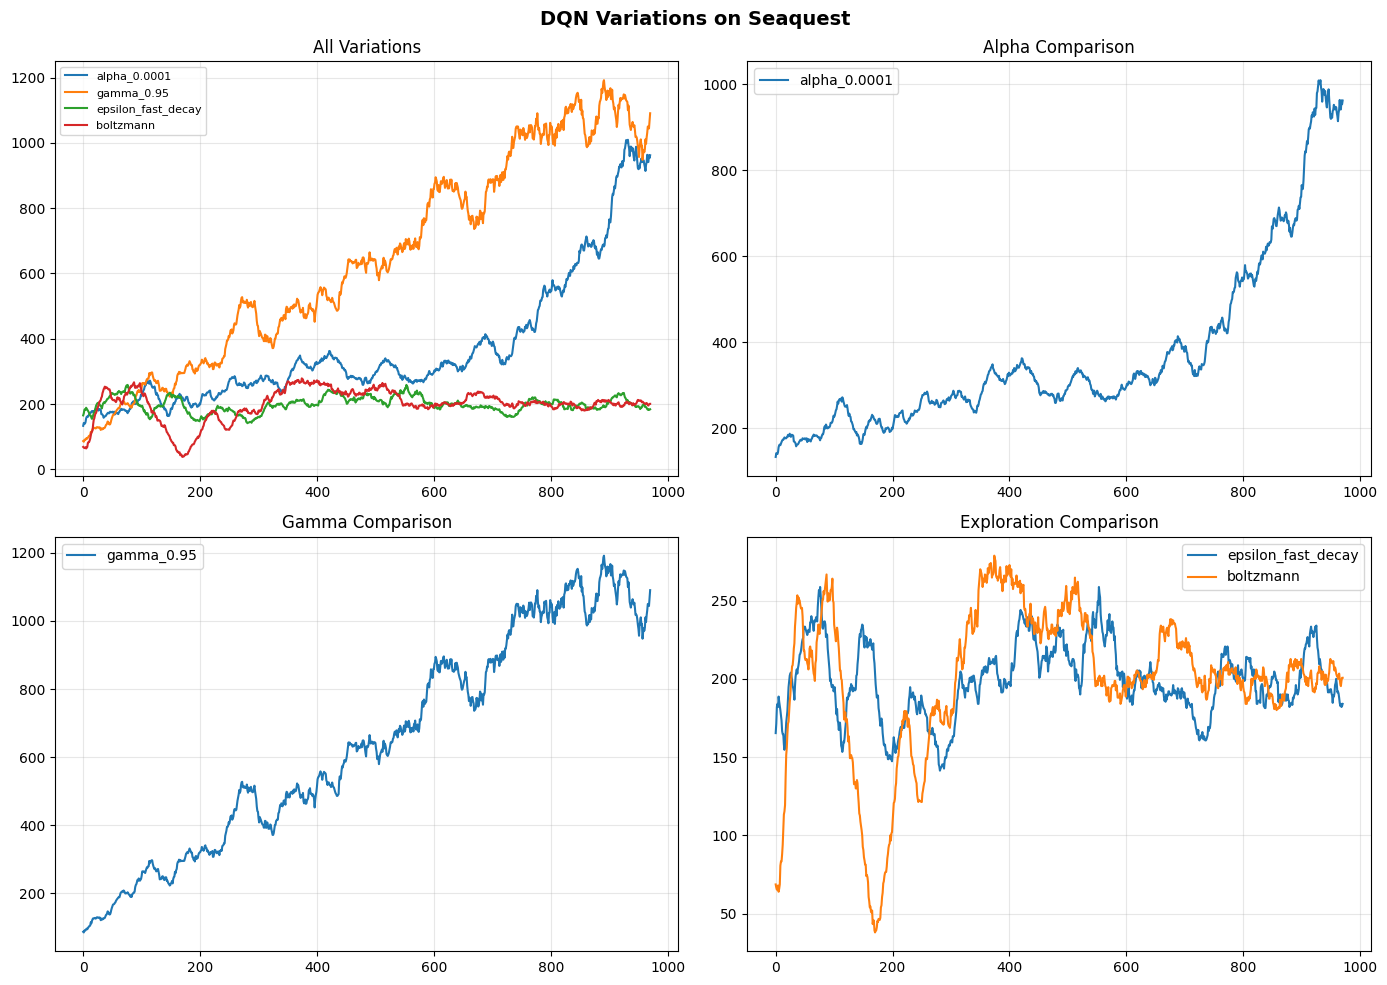


FILES SAVED TO /kaggle/working/models/
  alpha_0.0001.pth                              6618.9 KB
  alpha_0.0001_output.txt                       1.0 KB
  boltzmann.pth                                 6618.8 KB
  boltzmann_output.txt                          0.9 KB
  epsilon_fast_decay.pth                        6619.0 KB
  epsilon_fast_decay_output.txt                 1.0 KB
  gamma_0.95.pth                                6618.9 KB
  gamma_0.95_output.txt                         1.0 KB
  results_summary.json                          0.6 KB
  variations_comparison.png                     321.5 KB

✓ Done! All models, logs, plot, and summary saved.


In [3]:
# ============================================================================= 
# CELL 3: Load Baseline Model & Store Results
# ============================================================================= 
import os, sys, io, json
from contextlib import redirect_stdout

SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

BASELINE_MODEL_PATH = "/kaggle/input/models/rohanprabhakar1103/deepq-atari/other/default/1/baseline_final.pth"

baseline_config = DQNConfig(total_episodes=5000)
baseline_agent = DQNAgent(baseline_config)
baseline_agent.load_model(BASELINE_MODEL_PATH)

all_results = {}
all_results['baseline'] = {
    'mean': 387.35,
    'max': 940.00,
    'test': 319.20,
    'config': 'α=0.00025, γ=0.99, ε=1.0→0.01',
    'model_path': BASELINE_MODEL_PATH,
    'output': 'Pre-trained baseline — no training output'
}
print("✓ Baseline loaded\n")


# ============================================================================= 
# HELPER: Train, test, save model + capture stdout
# ============================================================================= 
def run_experiment(name, agent, config_str):
    """Trains agent, saves .pth, captures stdout, returns result dict."""
    # --- Capture training output ---
    buf = io.StringIO()
    with redirect_stdout(buf):
        agent.train()
    train_output = buf.getvalue()

    # --- Test ---
    buf2 = io.StringIO()
    with redirect_stdout(buf2):
        test = agent.test(n_episodes=20)
    test_output = buf2.getvalue()

    # --- Save model weights ---
    model_path = os.path.join(SAVE_DIR, f"{name}.pth")
    torch.save(agent.policy_net.state_dict(), model_path)
    print(f"✓ [{name}] model saved → {model_path}")

    # --- Save captured output to txt ---
    log_path = os.path.join(SAVE_DIR, f"{name}_output.txt")
    with open(log_path, "w") as f:
        f.write(f"=== TRAINING OUTPUT: {name} ===\n")
        f.write(f"Config: {config_str}\n\n")
        f.write(train_output)
        f.write(f"\n=== TEST OUTPUT ===\n")
        f.write(test_output)
    print(f"✓ [{name}] log saved   → {log_path}")

    # Also echo to notebook
    print(train_output[-2000:] if len(train_output) > 2000 else train_output)

    return {
        'rewards':    agent.episode_rewards,
        'mean':       np.mean(agent.episode_rewards),
        'max':        np.max(agent.episode_rewards),
        'test':       test['mean_reward'],
        'config':     config_str,
        'model_path': model_path,
        'log_path':   log_path,
    }


# ============================================================================= 
# CELL 4: Run All Variations
# ============================================================================= 
VARIATION_EPISODES = 1000

# --- 1. ALPHA ---
print("="*60)
print("EXPERIMENT 1: ALPHA")
print("="*60)
config = DQNConfig(total_episodes=VARIATION_EPISODES, learning_rate=0.0001, log_freq=100)
agent  = DQNAgent(config)
all_results['alpha_0.0001'] = run_experiment('alpha_0.0001', agent, 'α=0.0001')

# --- 2. GAMMA ---
print("\n" + "="*60)
print("EXPERIMENT 2: GAMMA")
print("="*60)
config = DQNConfig(total_episodes=VARIATION_EPISODES, gamma=0.95, log_freq=100)
agent  = DQNAgent(config)
all_results['gamma_0.95'] = run_experiment('gamma_0.95', agent, 'γ=0.95')

# --- 3. EPSILON ---
print("\n" + "="*60)
print("EXPERIMENT 3: EPSILON")
print("="*60)
config = DQNConfig(total_episodes=VARIATION_EPISODES, epsilon_decay=0.00005, log_freq=100)
agent  = DQNAgent(config)
all_results['epsilon_fast_decay'] = run_experiment('epsilon_fast_decay', agent, 'decay=0.00005')

# --- 4. BOLTZMANN ---
print("\n" + "="*60)
print("EXPERIMENT 4: BOLTZMANN POLICY")
print("="*60)

class BoltzmannAgent(DQNAgent):
    def __init__(self, config):
        super().__init__(config)
        self.temp = 1.0

    def select_action(self, state):
        self.temp = 0.1 + 0.9 * np.exp(-0.00001 * self.total_steps)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q = self.policy_net(state_t).cpu().numpy().flatten()
        q = q - np.max(q)
        exp_q = np.exp(q / max(self.temp, 0.01))
        probs  = exp_q / np.sum(exp_q)
        return np.random.choice(self.n_actions, p=probs)

config = DQNConfig(total_episodes=VARIATION_EPISODES, log_freq=100)
agent  = BoltzmannAgent(config)
all_results['boltzmann'] = run_experiment('boltzmann', agent, 'Boltzmann T=1→0.1')

print("\n✓ All 4 experiments complete!")


# ============================================================================= 
# CELL 5: Results Table + save JSON summary
# ============================================================================= 
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"\n{'Experiment':<22} {'Mean':<10} {'Max':<10} {'Test':<10} {'vs Baseline'}")
print("-"*64)

baseline_test = all_results['baseline']['test']
summary = {}

for name, data in all_results.items():
    mean = data.get('mean', data.get('test', 0))
    max_r = data.get('max', mean)
    test  = data.get('test', mean)
    vs    = "---" if name == 'baseline' else f"{'↑' if test > baseline_test else '↓'}{abs(test - baseline_test):.1f}"
    print(f"{name:<22} {mean:<10.1f} {max_r:<10.1f} {test:<10.1f} {vs}")
    summary[name] = {'mean': round(mean,2), 'max': round(max_r,2),
                     'test': round(test,2), 'config': data['config']}

# Save JSON summary
summary_path = os.path.join(SAVE_DIR, "results_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n✓ Summary saved → {summary_path}")


# ============================================================================= 
# CELL 6: Plots
# ============================================================================= 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DQN Variations on Seaquest', fontsize=14, fontweight='bold')

experiments_with_data = {k: v for k, v in all_results.items() if 'rewards' in v}

# Plot 1: All variations
ax1 = axes[0, 0]
for name, data in experiments_with_data.items():
    ma = np.convolve(data['rewards'], np.ones(30)/30, mode='valid')
    ax1.plot(ma, label=name)
ax1.set_title('All Variations'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Plot 2: Alpha
ax2 = axes[0, 1]
for name in ['alpha_0.0001', 'alpha_0.001']:
    if name in experiments_with_data:
        ma = np.convolve(experiments_with_data[name]['rewards'], np.ones(30)/30, mode='valid')
        ax2.plot(ma, label=name)
ax2.set_title('Alpha Comparison'); ax2.legend(); ax2.grid(True, alpha=0.3)

# Plot 3: Gamma
ax3 = axes[1, 0]
for name in ['gamma_0.9', 'gamma_0.95']:
    if name in experiments_with_data:
        ma = np.convolve(experiments_with_data[name]['rewards'], np.ones(30)/30, mode='valid')
        ax3.plot(ma, label=name)
ax3.set_title('Gamma Comparison'); ax3.legend(); ax3.grid(True, alpha=0.3)

# Plot 4: Exploration
ax4 = axes[1, 1]
for name in ['epsilon_fast_decay', 'boltzmann']:
    if name in experiments_with_data:
        ma = np.convolve(experiments_with_data[name]['rewards'], np.ones(30)/30, mode='valid')
        ax4.plot(ma, label=name)
ax4.set_title('Exploration Comparison'); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, "variations_comparison.png")
plt.savefig(plot_path, dpi=150)
plt.show()

# ============================================================================= 
# CELL 7: Print all saved files
# ============================================================================= 
print("\n" + "="*60)
print("FILES SAVED TO /kaggle/working/models/")
print("="*60)
for f in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f)
    size  = os.path.getsize(fpath)
    print(f"  {f:<45} {size/1024:.1f} KB")

print("\n✓ Done! All models, logs, plot, and summary saved.")